## Preamble

### Learning Objectives

In this microcredit course on diffusion models, participants will:

 - Understand foundational concepts such as deconvolution and upsampling in image processing.
 - Explore autoencoders and variational autoencoders as precursors to generative models.
 - Gain an in-depth understanding of diffusion models, including their training and operational mechanisms.
 - Develop practical skills in implementing and evaluating diffusion models for tasks like image generation, inpainting, and denoising.
 - Discover the real-world applications of diffusion models in generative image processing.

### Repositories
*https://gitlab-aidl-fi.ostfalia.de/ki4all/ki4all/-/tree/main/Microcredits*

### Extent
1 ECTS
                                                                                                                                                                                                 
### Prerequisites

The reader should have:

- High school mathematics knowledge.
- Proficiency in Python programming language.
- Familiarity with NumPy, matplotlib, and PyTorch libraries.
- Understanding of basic machine learning and computer vision concepts.


### Target Audience

This microcredit course is tailored for students and the general public interested in comprehending the fundamental principles underlying Diffusion models.
                                                                                                                                                                                                
### Authors

1. *M.Sc. Srinivas Kachavarapu*
2. *M.Sc. Rajababu Singh*
3. *Prof. Dr. rer. nat. Carsten Meyer*

### Contact Details
                                                                                                                                                                                
Prof. Dr. Carsten Meyer    
Faculty of Computer Science    
Ostfalia University of Applied Sciences    
38302 Wolfenbüttel,    
Germany

# **List of Contents**

#### 0. [Setup](#0-setup)
#### 1. [Introduction](#1-introduction)
#### 2. [UpSampling](#2-upsampling)
* #### 2.1 [Different ways of UpSampling](#21-different-ways-of-upsampling)
* #### 2.2 [Interpolation](#22-interpolation)
* #### 2.3 [Max Unpooling](#23-max-unpooling)
* #### 2.4 [Transposed Convolution](#24-transposed-convolution)

#### 3. [Autoencoders](#3-autoencoders)
* #### 3.1 [Introduction to Autoencoders](#31-introduction-to-autoencoders)
* #### 3.2 [Fundamentals of Autoencoder](#32-fundamentals-of-autoencoder)
* #### 3.3 [Types of Autoencoders](#33-types-of-autoencoders)
* #### 3.4 [U-Net Autoencoder](#34-u-net-autoencoder)

#### 4. [Diffusion Models](#4-diffusion-models)
* #### 4.1 [Diffusion Processes: Formulations](#41-diffusion-process)
* #### 4.2 [Forward Process](#42-forward-process)
* #### 4.3 [Reverse Process](#43-reverse-process)
* #### 4.4 [Inference](#44-inference)
* #### 4.5 [Training](#45-training)
* #### 4.6 [Unconditional Diffusion Models](#46-unconditional-diffusion-models)
* #### 4.7 [Fine Tuning](#47-fine-tuning)
* #### 4.8 [From Theory to Systems](#48-systems)
* #### 4.9 [Summary](#49-summary)

#### 5. [Implementation](#5-implementation)
* #### 5.1 [Setup](#51-setup)
* #### 5.2 [Forward Pass (DDPM)](#52-forward-pass-ddpm)
* #### 5.3 [Forward Pass (SDE)](#53-forward-pass-sde)
* #### 5.4 [Simple U-Net (Shared)](#54-simple-u-net-shared)
* #### 5.5 [Reverse Pass (DDPM)](#55-reverse-pass-ddpm)
* #### 5.6 [Reverse Pass (SDE)](#56-reverse-pass-sde)

#### 6. [References](#6-references)


In [1]:
# excute this cell or command in the terminal to install Prerequisites
! pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


# Setup <a  id="0-setup"></a>

In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, UpSampling2D, Conv2DTranspose
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Introduction <a class="anchor" id="1-introduction"></a>
This course is structured to show students how modern generative AI in computer vision emerged from a clear historical and technical progression: first, classical computer vision and early convolutional networks became highly effective at extracting compact, meaningful features, but this also reduced spatial resolution, creating the need for upsampling methods that could reconstruct detailed high-resolution outputs from compressed feature maps, especially in tasks such as semantic segmentation and image-to-image prediction. From there, autoencoders became important because they formalized the encoder-decoder idea of compressing data into a latent representation and reconstructing it, offering a practical way to learn compact structure in high-dimensional images while also introducing denoising and probabilistic variants that directly foreshadow the logic of diffusion models. In segmentation, this evolution led to architectures such as U-Net, where upsampling was combined with decoder pathways and skip connections to recover fine spatial detail lost during downsampling, making precise pixel-level prediction possible and demonstrating how learned reconstruction could be as important as feature extraction itself. These same ideas later expanded beyond analysis into synthesis: once models could encode images, preserve structure, and reconstruct detail through learned decoders, the field moved naturally toward generative modeling, where denoising autoencoders, variational autoencoders, and finally diffusion models transformed reconstruction principles into powerful image generation systems capable of producing realistic images, inpainting missing content, and synthesizing new visual data, which is why the range of topics in this material is not separate but forms one coherent pathway from foundational vision operations to modern generative AI in computer vision.



# 2 . UpSampling <a class="anchor" id="2-upsampling"></a>


In many computer vision tasks, convolutional neural networks first compress images into compact feature maps using convolutions and pooling, thereby losing spatial resolution but gaining high‑level semantic information. For tasks such as semantic segmentation, image‑to‑image translation, or generative models like autoencoders and diffusion models, the network must later reconstruct a high‑resolution output from these low‑resolution feature maps [[15]](#ref-15). Upsampling layers provide this reconstruction step either through simple interpolation rules or learned transformations such as transposed convolutions, so that low-resolution feature maps match the original image size or another desired resolution [[16]](#ref-16).
$$
\begin{array}{c}
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
\\[6pt]
\text{Low-dimensional Input (2x2)}
\end{array}
\quad
\overset{\text{Upsampling}}{\Longrightarrow}
\quad
\begin{array}{c}
\begin{bmatrix}
a & a & b & b \\
a & a & b & b \\
c & c & d & d \\
c & c & d & d
\end{bmatrix}
\\[6pt]
\text{High-dimensional Output (4x4)}
\end{array}
$$

##### 2.1) Different ways of UpSampling <a class="anchor" id="21-different-ways-of-upsampling"></a>

There are many ways on how upsampling can be done: choosing a particular upsampling technique depends on several factors related to the task, the nature of the data, and the goals of the model or algorithm. Common methods include interpolation (nearest/bilinear), max unpooling (using pooling indices),
and transposed convolution (learnable filters); these methods are explained in more detail in the following.

##### 2.2) Interpolation <a class="anchor" id="22-interpolation"></a>
The most direct way to upsample an image is interpolation, where new pixels are created by copying or averaging existing pixels according to a simple geometric rule. Image interpolation estimates new pixel values for resizing or transforming images by using surrounding known pixels, crucial for smooth upscaling (zooming in) or downscaling, with common methods like nearest neighbor interpolation or bilinear interpolation. Generally, nearest neighbor interpolation is fast, but yields limited quality, while bilinear interpolation  produces smoother results at the expense of more computations.

**Nearest neighbor interpolation:**
Nearest neighbor interpolation is a simple image interpolation method where each new pixel is assigned the value of the closest existing pixel, without averaging over multiple neighbours.

Below is an example. With nearest neighbor interpolation, the nearest pixel values are duplicated so that the output is expanded to the desired size. The example uses a 2x2 input matrix. Each pixel is repeated both horizontally and vertically to create a 4×4 output matrix, i.e., using an upsampling factor of 2 for both rows and columns.
$$
\begin{array}{c}
\begin{bmatrix} \color{red}{1} & \color{green}{2} \\ \color{blue}{3} & \color{orange}{4} \end{bmatrix} \\
\text{Low-dimensional Input (2×2)}
\end{array}
\overset{\text{Nearest Neighbor Interpolation}}{\quad \Rightarrow \quad}  
\begin{array}{c}
\begin{bmatrix} \color{red}{1} & \color{red}{1} & \color{green}{2} & \color{green}{2} \\ \color{red}{1} & \color{red}{1} & \color{green}{2} & \color{green}{2} \\ \color{blue}{3} & \color{blue}{3} & \color{orange}{4} & \color{orange}{4} \\ \color{blue}{3} & \color{blue}{3} & \color{orange}{4} & \color{orange}{4} \end{bmatrix} \\
\text{High-dimensional Output (4×4)}
\end{array}
$$

**Bilinear interpolation:** Bilinear interpolation estimates a new pixel's value as the weighted average of the four nearest surrounding pixels (forming a 2×2 neighborhood), performing linear interpolation first horizontally then vertically.


Below is an example using the same (2x2) input matrix. Again, each pixel is repeated both horizontally and vertically to create a (4×4) output matrix, this time using bilinear interpolation:

$$
\begin{array}{c}
\begin{bmatrix} \color{red}{1} & \color{green}{2} \\ \color{blue}{3} & \color{orange}{4} \end{bmatrix} \\
\text{Low-dimensional Input(2×2)}
\end{array}
\overset{\text{Bilinear Interpolation}}{\quad \Rightarrow \quad}  
\begin{array}{c}
\begin{bmatrix} \color{red}{1} & \color{red}{1.25} & \color{green}{1.75} & \color{green}{2} \\ \color{red}{1.5} & \color{red}{1.75} & \color{green}{2.25} & \color{green}{2.5} \\ \color{blue}{2.5} & \color{blue}{2.75} & \color{orange}{3.25} & \color{orange}{3.5} \\ \color{blue}{3} & \color{blue}{3.25} & \color{orange}{3.75} & \color{orange}{4} \end{bmatrix} \\
\text{High-dimensional Output (4×4)}
\end{array}
$$

In deep learning frameworks such as Keras, interpolation can be applied using the UpSampling2D layer, which resizes feature maps by a specified scale factor and interpolative resizing techniques such as nearest neighbour interpolation or bilinear interpolation. In Keras the desired technique is specified using the **interpolation** argument (for example **interpolation="nearest"** for nearest neighbor interpolation).

In [ ]:
x = np.array([[[[1.],[2.]],[[3.],[4.]]]])  # shape (1, 2, 2, 1)

nearest = tf.keras.layers.UpSampling2D(size=(2, 2), interpolation='nearest')(x)
bilinear = tf.keras.layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(x)

print('Nearest:', nearest.numpy().squeeze())
print('Bilinear:', bilinear.numpy().squeeze())

##### 2.3) Max Unpooling <a class="anchor" id="23-max-unpooling"></a>

Max unpooling in some sense "reverses" max pooling (note that it is not a mathematical inverse!) by placing each input value of the low-dimensional input at the location in the high-dimensional output which held the maximum value in the corresponding pooling operation of the encoder, and filling all other positions with zeros. The positions of the maxima in the pooling operation are stored in a mask of "pooling indices" (also called "switch variables"), which are then used in the unpooling step. In this way, spatial information from the downsampling or encoder is preserved without creating new values through interpolation [[20]](#ref-20).


$$
\begin{array}{c}
\begin{bmatrix}
\color{red}{5} & \color{red}{6} & \color{green}{7} & \color{green}{9} \\
\color{red}{9} & \color{red}{10} & \color{green}{11} & \color{green}{2} \\
\color{blue}{3} & \color{blue}{9} & \color{orange}{6} & \color{orange}{9} \\
\color{blue}{3} & \color{blue}{10} & \color{orange}{4} & \color{orange}{5}
\end{bmatrix} \\
\text{Input (4×4)}
\end{array}
\overset{\text{Max Pooling}}{\quad \Rightarrow \quad}  
\begin{array}{c}
\begin{bmatrix}
\color{red}{10} & \color{green}{11} \\
\color{blue}{10} & \color{orange}{9}
\end{bmatrix} \\
\text{Downsample (2×2)}
\end{array}
\overset{\text{Mask}}{\quad \Rightarrow \quad}
\begin{array}{c}
\begin{bmatrix}
\color{red}{0} & \color{red}{0} & \color{green}{0} & \color{green}{0} \\
\color{red}{0} & \color{red}{X} & \color{green}{X} & \color{green}{0} \\
\color{blue}{0} & \color{blue}{0} & \color{orange}{0} & \color{orange}{X} \\
\color{blue}{0} & \color{blue}{X} & \color{orange}{0} & \color{orange}{0}
\end{bmatrix} \\
\text{Location of maximum values (pooling indices, switch variables)}
\end{array} \qquad \qquad
\overset{\text{}}{\quad \cdots}
\begin{array}{c}
\begin{bmatrix}
\color{red}{5} & \color{green}{7} \\
\color{blue}{8} & \color{orange}{3}
\end{bmatrix} \\
\text{input (2×2)}
\end{array}
\overset{\text{Max Unpooling}}{\quad \Rightarrow \quad}
\begin{array}{c}
\begin{bmatrix}
\color{red}{0} & \color{red}{0} & \color{green}{0} & \color{green}{0} \\
\color{red}{0} & \color{red}{5} & \color{green}{7} & \color{green}{0} \\
\color{blue}{0} & \color{blue}{0} & \color{orange}{0} & \color{orange}{8} \\
\color{blue}{0} & \color{blue}{3} & \color{orange}{0} & \color{orange}{0}
\end{bmatrix} \\
\text{Reconstructed Output (4×4)}
\end{array}
$$
In the above example, a 4×4 input undergoes 2×2 max pooling (stride 2), producing a 2×2 downsampled output where each value represents the maximum from its 2×2 quadrant. The pooling indices (switch variables) record these maximum positions (marked X). For unpooling with a different 2×2 input, the input values are inserted at the remembered locations from the pooling indices (switch variables) while zeros fill the rest, yielding the sparse 4×4 output that maintains the original spatial structure from the encoder.
Usually, max unpooling is followed by several standard convolutions which fill the missing (zero) values.


##### 2.4) Transposed convolution <a class="anchor" id="24-transposed-convolution"></a>
Transposed convolution upsamples feature maps by applying learnable filters that distribute each input value across a larger spatial neighborhood, enabling the network to adapt spatial features for tasks such as segmentation or generation.  Unlike fixed interpolation methods such as UpSampling2D or sparse max unpooling, it learns filter weights during training to create new output values tailored to the data. While it was historically often called *deconvolution*, more precise terms today are **transposed convolution**, **learnable upsampling**, or **fractionally strided convolution**. Note that it does **not** compute the inverse of a convolution operation; rather, it is called *transposed* because it corresponds to the transpose of the matrix representation of convolution.
### Step-by-step process 
**Low-dimensional Input (2×2)**
$$
\begin{bmatrix}
\color{red}{1} & \color{green}{2} \\
\color{blue}{3} & \color{orange}{4}
\end{bmatrix}
$$

**Kernel (filter)**

$$
\begin{bmatrix}
\color{red}{1} & \color{red}{4} & \color{red}{1} \\
\color{red}{1} & \color{red}{4} & \color{red}{3} \\
\color{red}{3} & \color{red}{3} & \color{red}{1}
\end{bmatrix}
$$




**Apply Kernel to First Input Value: 1**
$$
\begin{bmatrix}
\color{red}{1} & \color{red}{4} & \color{red}{1} \\
\color{red}{1} & \color{red}{4} & \color{red}{3} \\
\color{red}{3} & \color{red}{3} & \color{red}{1}
\end{bmatrix}
\overset{\times 1}{\Rightarrow}
\begin{bmatrix}
\color{red}{1} & \color{red}{4} & \color{red}{1} & 0 \\
\color{red}{1} & \color{red}{4} & \color{red}{3} & 0 \\
\color{red}{3} & \color{red}{3} & \color{red}{1} & 0 \\
0 & 0 & 0 & 0
\end{bmatrix}
$$

---

**Apply Kernel to Second Input Value: 2**
$$
\begin{bmatrix}
\color{green}{1} & \color{green}{4} & \color{green}{1} \\
\color{green}{1} & \color{green}{4} & \color{green}{3} \\
\color{green}{3} & \color{green}{3} & \color{green}{1}
\end{bmatrix}
\overset{\times 2}{\Rightarrow}
\begin{bmatrix}
0 & \color{green}{2} & \color{green}{8} & \color{green}{2} \\
0 & \color{green}{2} & \color{green}{8} & \color{green}{6} \\
0 & \color{green}{6} & \color{green}{6} & \color{green}{2} \\
0 & 0 & 0 & 0
\end{bmatrix}
$$

---

**Apply Kernel to Third Input Value: 3**
$$
\begin{bmatrix}
\color{blue}{1} & \color{blue}{4} & \color{blue}{1} \\
\color{blue}{1} & \color{blue}{4} & \color{blue}{3} \\
\color{blue}{3} & \color{blue}{3} & \color{blue}{1}
\end{bmatrix}
\overset{\times 3}{\Rightarrow}
\begin{bmatrix}
0 & 0 & 0 & 0 \\
\color{blue}{3} & \color{blue}{12} & \color{blue}{3} & 0 \\
\color{blue}{3} & \color{blue}{12} & \color{blue}{9} & 0 \\
\color{blue}{9} & \color{blue}{9} & \color{blue}{3} & 0
\end{bmatrix}
$$

---

**Apply Kernel to Fourth Input Value: 4**
$$
\begin{bmatrix}
\color{orange}{1} & \color{orange}{4} & \color{orange}{1} \\
\color{orange}{1} & \color{orange}{4} & \color{orange}{3} \\
\color{orange}{3} & \color{orange}{3} & \color{orange}{1}
\end{bmatrix}
\overset{\times 4}{\Rightarrow}
\begin{bmatrix}
0 & 0 & 0 & 0 \\
0 & \color{orange}{4} & \color{orange}{16} & \color{orange}{4} \\
0 & \color{orange}{4} & \color{orange}{16} & \color{orange}{12} \\
0 & \color{orange}{12} & \color{orange}{12} & \color{orange}{4}
\end{bmatrix}
$$

---

**Sum All Matrices to Obtain Output (4×4)**
$$
\begin{bmatrix}
\color{red}{1} & \color{red}{4} & \color{red}{1} & 0 \\
\color{red}{1} & \color{red}{4} & \color{red}{3} & 0 \\
\color{red}{3} & \color{red}{3} & \color{red}{1} & 0 \\
0 & 0 & 0 & 0
\end{bmatrix}
+
\begin{bmatrix}
0 & \color{green}{2} & \color{green}{8} & \color{green}{2} \\
0 & \color{green}{2} & \color{green}{8} & \color{green}{6} \\
0 & \color{green}{6} & \color{green}{6} & \color{green}{2} \\
0 & 0 & 0 & 0
\end{bmatrix}
+
\begin{bmatrix}
0 & 0 & 0 & 0 \\
\color{blue}{3} & \color{blue}{12} & \color{blue}{3} & 0 \\
\color{blue}{3} & \color{blue}{12} & \color{blue}{9} & 0 \\
\color{blue}{9} & \color{blue}{9} & \color{blue}{3} & 0
\end{bmatrix}
+
\begin{bmatrix}
0 & 0 & 0 & 0 \\
0 & \color{orange}{4} & \color{orange}{16} & \color{orange}{4} \\
0 & \color{orange}{4} & \color{orange}{16} & \color{orange}{12} \\
0 & \color{orange}{12} & \color{orange}{12} & \color{orange}{4}
\end{bmatrix}
$$

**Summing element-wise:**

$$
\begin{bmatrix}
(1+0+0+0) & (4+2+0+0) & (1+8+0+0) & (0+2+0+0) \\
(1+0+3+0) & (4+2+12+4) & (3+8+3+16) & (0+6+0+4) \\
(3+0+3+0) & (3+6+12+4) & (1+6+9+16) & (0+2+0+12) \\
(0+0+9+0) & (0+0+9+12) & (0+0+3+12) & (0+0+0+4)
\end{bmatrix}
$$

**Final upsampled output (4x4):**

$$
\begin{bmatrix}
1 & 6 & 9 & 2 \\
4 & 22 & 30 & 10 \\
6 & 25 & 32 & 14 \\
9 & 21 & 15 & 4
\end{bmatrix}
$$



# 3 . Autoencoders <a class="anchor" id="3-autoencoders"></a>
---

### 3.1 Introduction to Autoencoders <a class="anchor" id="31-introduction-to-autoencoders"></a>


Before delving into [Section 4](#4.-Diffusion-Models) of diffusion models it is
important to first understand the concept of an autoencoder, as it
provides a useful foundation for comprehending the principles underlying
diffusion models. In the age of data-driven solutions, very high-dimensional
data pose a unique challenge known as the *curse of dimensionality*
[[22]](#ref-22). As the number of dimensions increases, the volume of
the feature space grows exponentially, causing data points to become sparse
and making it more difficult for models to learn meaningful patterns.
This phenomenon makes it difficult to model, process, and interpret vast
data spaces efficiently, leading to computational inefficiency and increased
model complexity [[23]](#ref-23). Traditional machine learning algorithms
like Principal Component Analysis (PCA) [[26]](#ref-26) and t-Distributed
Stochastic Neighbor Embedding (t-SNE) [[34]](#ref-34) have historically
been applied to reduce dimensionality, simplifying data representation and
uncovering underlying patterns. An alternative approach that has emerged
in the last decade is the autoencoder [[25]](#ref-25).
Autoencoders help address this issue by compressing high-dimensional input
data into a lower-dimensional latent representation that captures the most
important underlying structure. The encoder maps the input to a compact
latent space, and the decoder reconstructs the original data from this
representation. In particular, a denoising autoencoder learns to recover
clean data from a noisy version, which closely relates to the central
idea of diffusion models [[28]](#ref-28). While a standard autoencoder
performs this reconstruction in a single deterministic step, diffusion models
extend this concept by gradually adding noise to the data and then
learning to remove it step by step in a stochastic manner. Thus, diffusion
models can be viewed as a multi-step, probabilistic extension of the
denoising autoencoder, enabling them to model complex data distributions
and generate high-quality samples [[1]](#ref-1).




### 3.2 Fundamentals of Autoencoder <a class="anchor" id="32-fundamentals-of-autoencoder"></a>

In [4]:
from IPython.display import display, HTML

In [5]:
caption_html = """
<figure>
    <center>
  <img src="./images/autoencoder.svg" alt="Graph" />
  <figcaption style="text-align:center; font-style: italic;">
    Figure 3.2.1: An autoencoder with three layers of encoder and decoder, and one layer of latent space.
  </figcaption>
</figure>
"""
display(HTML(caption_html))

An autoencoder (see Fig. 3.2.1) is a type of neural network model
specifically designed for unsupervised learning, often utilized in dimensionality
reduction and data generation tasks [[25]](#ref-25). It is
composed of two primary parts:

1. **Encoder:** The encoder maps high-dimensional input data, represented as $x$,
   to a compressed latent space representation $z$. This function can be formally
   expressed as:
   $$
   z = f_{\text{encoder}}(x)
   $$
   Here, $f_{\text{encoder}}$ is the encoder function, which learns essential
   features from the input, enabling a lower-dimensional representation while
   retaining key data characteristics [[23]](#ref-23).

2. **Decoder:** The decoder reconstructs the original high-dimensional data from
   the latent representation $z$. This process can be described with:
   $$
   y = f_{\text{decoder}}(z)
   $$
   where $y$ represents the reconstructed data, and $f_{\text{decoder}}$ is the
   decoder function. The decoder’s objective is to closely approximate the
   original data, thus capturing meaningful patterns within the latent space
   [[28]](#ref-28).

This architecture allows autoencoders to capture intrinsic data representations,
facilitating tasks like dimensionality reduction, data compression, and others
[[24]](#ref-24).

Autoencoders tackle the curse of dimensionality by transforming data into a
reduced feature space, which minimizes redundant information [[22]](#ref-22).
Through backpropagation, the model learns to optimize reconstruction, preserving
essential information while reducing the dimensionality of the input. The encoder
learns a compact, informative latent representation, which reduces computational
requirements for subsequent tasks [[25]](#ref-25).

Autoencoders are widely applicable across various fields due to their ability to
capture and generate representations. Some notable applications include:

- **Dimensionality Reduction:** By learning compressed representations, autoencoders
  provide an alternative to PCA for high-dimensional data [[26]](#ref-26).
- **Data Generation and Anomaly Detection:** With their reconstruction capabilities,
  autoencoders detect anomalies when data reconstruction errors exceed a defined
  threshold [[27]](#ref-27).
- **Denoising:** Autoencoders can learn to filter noise from data by reconstructing
  clean data representations [[28]](#ref-28).

Through these applications, autoencoders have become indispensable in machine learning,
particularly in unsupervised and semi-supervised learning scenarios [[24]](#ref-24).


### 3.3 Types of Autoencoders <a class="anchor" id="33-types-of-autoencoders"></a>

1. **Vanilla Autoencoder** <br>
This is the basic form of an autoencoder, where both the encoder and decoder
are simple neural networks, typically composed of fully connected layers. The
goal is to reconstruct the input with minimal loss [[25]](#ref-25).

2. **Denoising Autoencoder (DAE)** <br>
Denoising autoencoders are designed to encourage the model to learn
meaningful representations by reconstructing clean data from corrupted inputs.
In a denoising autoencoder, noise is explicitly added to the input data before
the training process begins—for example, random noise may be added to an input
image to corrupt it. The encoder then receives this noisy version of the input
and learns to extract a meaningful latent representation despite the corruption.
The decoder reconstructs the data from this representation, and the reconstructed
output is finally compared with the original clean input image (without noise).
The objective is to minimize the reconstruction loss between the clean image and
the reconstructed output. In this way, noise serves as a regularization technique,
encouraging the model to learn robust and meaningful features rather than simply
memorizing the training data [[28]](#ref-28).

3. **Sparse Autoencoder** <br>
Sparse autoencoders enforce a sparsity constraint on the latent representation,
so that only a small subset of neurons is active for any given input. This
encourages the network to learn more meaningful and disentangled features,
which is useful not only for feature extraction but also for representation
learning in high-dimensional data [[35]](#ref-35).

4. **Variational Autoencoder (VAE)** <br>

- Before delving into [Section 4](#4.-Diffusion-Models) on diffusion models, it is
important to first understand variational autoencoders (VAEs) because diffusion
models rely on stochastic sampling to generate data, and grasping VAEs provides
a foundational insight into probabilistic latent representations [[11]](#ref-11).
VAEs bridge the gap between standard deterministic autoencoders and fully
stochastic generative models like diffusion models.

- In a VAE, the encoder does not produce a fixed latent vector; instead, it
learns the **mean** ($\mu$) and **variance** ($\sigma^2$) of the latent
distribution (which is assumed to be Gaussian) for each input. Latent vectors $z$ are then sampled from this
distribution, and the decoder reconstructs the data from these samples
[[11]](#ref-11) [[32]](#ref-32m). This stochastic latent space allows
VAEs to produce robust representations and make them **powerful generative models**
capable of generating realistic synthetic data.  

- Both VAEs and diffusion models share the core idea of learning a latent
representation and sampling from it to generate or reconstruct data, which makes
VAEs an essential conceptual stepping stone before exploring diffusion models
[[32]](#ref-32).


- The VAE is trained to minimize a loss that combines reconstruction loss
and KL divergence. The reconstruction loss ensures that the reconstructed
output $\hat{x}$ is similar to the original input $x$, while the KL
divergence regularizes the latent distribution to be close to a standard
normal distribution $\mathcal{N}(0, I)$ [[11]](#ref-11) [[32]](#ref-32).
This training objective ensures that the latent space captures meaningful
features, allows stochastic sampling, and enables the VAE to generate realistic
new data [[11]](#ref-11) [[32]](#ref-32).


5. **Contractive Autoencoder** <br>
Contractive autoencoders add a penalty term to the loss function to minimize
the sensitivity of the latent representation to small changes in the input. This
encourages the network to learn representations that are **robust to variations**
in the input, which is useful for tasks requiring invariance to slight
modifications [[36]](#ref-36).


### 3.4 U-Net Autoencoder <a class="anchor" id="34-u-net-autoencoder"></a>

<figure>
    <center>
  <img src="./images/unet.png" alt="Graph" />
  <figcaption style="text-align:center; font-style: italic;">
    Figure 3.4.1: U-Net Architecture <a href="#ref-48">[48]</a>  with Skip Connections – Preserving spatial information using skip connections to enhance accuracy and detail in image segmentation tasks.
  </figcaption>
</figure>

Before delving into the section on Diffusion Models, it is important to understand the U-Net architecture [[48]](#ref-48), as it serves as a core building block for image reconstruction in diffusion models. Although the architecture was originally introduced for biomedical image segmentation, where it performs particularly well, it has since been adapted for generative tasks. Similar to a standard autoencoder, U-Net consists of an encoder that extracts hierarchical features through downsampling and a decoder that reconstructs spatial resolution through upsampling. However, the key difference from a traditional autoencoder is the introduction of **skip connections** between corresponding encoder and decoder layers. These connections transfer high-resolution feature maps directly to the decoder, helping preserve spatial details that may otherwise be lost during the downsampling process.


# 4 . Diffusion Models <a class="anchor" id="4-diffusion-models"></a>


In the previous sections, we discussed upsampling techniques, encoder-decoder architectures like autoencoders and U-Net.

These structures form the backbone of many image processing tasks, including segmentation, super-resolution, and image synthesis, providing the foundational network design that diffusion models extend into probabilistic generative modeling. In this chapter, we provide theoretical insights into diffusion models, focusing on introducing image generation with diffusion models. Diffusion models have emerged as a powerful class of generative models and demonstrated unprecedented ability at generating high-quality and realistic images. Their superior performance is evident across a spectrum of applications, encompassing image and video synthesis,
denoising, super-resolution and layout-to-image synthesis [[17]](#ref-17).The popularity of diffusion models can be attributed to several factors. First, they offer a simple yet effective approach for generative modeling, often outperforming traditional approaches such as **Generative Adversarial
Networks (GANs)**  and **Variational Autoencoders (VAEs)** [[18]](#ref-18) in terms of visual
fidelity and sample diversity. Second, diffusion models are generally more stable and less prone to
mode collapse compared to GANs [[19]](#ref-19) and are shown to outperform GANs in image synthesis [[3]](#ref-3).

Diffusion models are inspired by the natural physical process of diffusion from non-equilibrium thermodynamics. They define a Markov chain of diffusion steps to add random noise to data slowly and then learn to reverse the diffusion process to construct desired data samples from the noise. Unlike **Variational autoencoder (VAE)** or **Flow-based models**, diffusion models are learned with a fixed procedure, and the latent variable has the same dimensionality as the original data [[4]](#ref-4). This enables diffusion models to avoid information bottlenecks and enables superior fidelity over other Generative models.

<figure>
    <center>
        <img src="./images/Different_generative_models.png" alt="Overview of different generative models" width="70%">
        <figcaption>
            Figure 4.1. Overview of different types of generative models <a href="#ref-4">[4]</a>.
        </figcaption>
    </center>
</figure>

This chapter introduces diffusion models with a focus on **intuitive explanations**, and the **minimal math** needed to understand how training and sampling work. We first describe the *forward (noising) process*, then the *reverse (denoising) process*, followed by *inference*, *training*, and *conditioning/guidance*.

Diffusion models comprise several related formulations, including variational, denoising, and score-based approaches; in this chapter, we focus primarily on denoising diffusion probabilistic models (DDPMs) as the main framework for explaining image generation, while briefly noting their connections to variational and continuous-time views.

Learning goals:
- Understand what the forward and reverse processes do.
- Read the main diffusion equations and interpret each symbol.
- Understand the practical training objective used in DDPMs.
- Understand how conditioning and guidance change the generation process.



## Notation

We will use the following symbols consistently throughout the chapter:

- **Data sample:** $\mathbf{x}_0 \in \mathbb{R}^{H \times W \times C}$ (e.g., an image). In formulas, we treat it as a vector.
- **Noised sample:** $\mathbf{x}_t$ is the sample after adding noise at step $t$.
- **Final noise:** $\mathbf{x}_T \sim \mathcal{N}(0, \mathbf{I})$ (pure Gaussian noise).
- **Steps:** $t = 1, 2, \dots, T$ (typically $T \approx 1000$).
- **Noise schedule:** $\beta_t \in (0,1)$, the variance added at step $t$.
- **Alpha:** $\alpha_t = 1 - \beta_t$, and $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$.
- **Forward process:** $q(\cdot)$ is **fixed** (not learned); it is defined by the chosen noise schedule.
- **Reverse process:** $p_\theta(\cdot)$ is **learned**; $\theta$ are the neural network parameters.
- **Noise:** $\boldsymbol{\epsilon} \sim \mathcal{N}(0, \mathbf{I})$.

### 4.1. Diffusion Processes: Formulations <a class="anchor" id="41-diffusion-process"></a>

Diffusion models work by starting with a clear image and gradually adding noise until the image becomes pure static. This is called the forward process. The model then learns how to reverse that corruption step by step, turning noise back into a realistic image. This reverse process is what allows it to generate new images from random noise.

In this section, we cover two key formulations for these processes:

First, the **discrete-time Denoising Diffusion Probabilistic Models (DDPM)** from Ho et al. (2020), which uses simple step-by-step noise addition and removal [[1]](#ref-1).

Second, the **continuous-time Stochastic Differential Equation (SDE)** formulation from Song et al. (2021), which views diffusion as a smooth physical process similar to Brownian motion [[10]](#ref-10).

Both approaches are unified under **score-based generative models** (also called score-based diffusion models), where the model learns the **score function** [[10]](#ref-10)

This score concept connects both frameworks:

- **DDPM** approximates the score in a **discrete-time** formulation.
- **SDE-based diffusion models** represent the process in **continuous time**, enabling more flexible sampling strategies.

### 4.2 . Forward Process <a class="anchor" id="42-forward-process"></a>


The **forward process** gradually corrupts a clean data sample $\mathbf{x}_0$ into pure noise by adding small amounts of Gaussian noise. This is a Markov chain: each step depends only on the previous step. The original data is transformed into a sample from an isotropic Gaussian distribution $\mathbf{x}_T \sim \mathcal{N}(0, \mathbf{I})$.


### 1) DDPM (discrete-time) forward process

In Denoising Diffusion Probabilistic Models (DDPMs), the forward process gradually corrupts a data sample by adding Gaussian noise over a sequence of $T$ timesteps.

Starting from a clean sample $ \mathbf{x}_0 \sim q(\mathbf{x}_0) $, the noising process is defined as a Markov chain:

$$
q(\mathbf{x}_{1:T} \mid \mathbf{x}_0) = \prod_{t=1}^{T} q(\mathbf{x}_t \mid \mathbf{x}_{t-1})
$$

where each transition is given by


$$
q(\mathbf{x}_t \mid \mathbf{x}_{t-1}) = \mathcal{N}\left(\mathbf{x}_t; \sqrt{1-\beta_t}\,\mathbf{x}_{t-1}, \beta_t \mathbf{I}\right)
$$
[[1]](#ref-1)

Here, $ \beta_t \in (0,1) $ is the variance schedule that controls how much noise is added at timestep $t$, and $ \mathbf{I} $ denotes the identity matrix.

### Closed-form sampling

A key property of the DDPM forward process is that $ \mathbf{x}_t $ can be sampled directly from $ \mathbf{x}_0 $ without simulating all intermediate steps:


$$
q(\mathbf{x}_t \mid \mathbf{x}_0) = \mathcal{N}\left(\mathbf{x}_t; \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0, (1-\bar{\alpha}_t)\mathbf{I}\right)
$$
[[1]](#ref-1)

Equivalently, this can be written in reparameterized form as

$$
\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}, \qquad \boldsymbol{\epsilon} \sim \mathcal{N}(0,\mathbf{I})
$$

This equation shows that $ \mathbf{x}_t $ is a combination of the clean sample and Gaussian noise. As $t$ increases, the contribution of the original signal decreases while the noise component becomes stronger.

**Practical intuition:** start with a clean image $\mathbf{x}_0$, add a little noise each step, and by $t = T$ the image looks like pure noise.

### 2) SDE (continuous-time) forward process 
The same idea can be expressed in continuous time using a stochastic differential equation (SDE):

$$
 d\mathbf{x}_t = f(\mathbf{x}_t, t)\,dt + g(t)\, d\mathbf{w}_t
$$ [[10]](#ref-10)

where $w$ is the **standard Wiener process** (a.k.a. Brownian motion),  
$f(\cdot, t): \mathbb{R}^d \rightarrow \mathbb{R}^d$ is a vector-valued function called the **drift coefficient** of $x(t)$, and  
$g(\cdot): \mathbb{R} \rightarrow \mathbb{R}$ is a scalar function known as the **diffusion coefficient** of $x(t)$.

The purpose of this forward process is to gradually transform samples from the data distribution $p_0$ into samples from a simple prior distribution $p_T$, typically a Gaussian distribution.

**Practical note:** If you are implementing a standard DDPM, you do not need the SDE formulation. It is mainly used to connect diffusion models with score-based methods and to design alternative samplers.


<figure>
    <center>
    <img title="a title" alt="Alt text" src="./images/forward_process.png" width="70%" Height=auto>
    <figcaption>
  Figure 4.2 The Markov chain of the forward and reverse diffusion process for generating a sample by gradually adding or removing noise <a href="#ref-1">[1]</a>.
</figcaption>
</figure>


### 4.3 . Reverse Process <a class="anchor" id="43-reverse-process"></a>

The **reverse process** starts from random noise $\mathbf{x}_T \sim \mathcal{N}(0, \mathbf{I})$ and gradually removes noise to recover a clean sample $\mathbf{x}_0$. Unlike the forward process, which is fixed and non-parameterized, the reverse process is modeled by a neural network trained to approximate the underlying data distribution.

### 1) DDPM reverse process (discrete time)
The reverse transition is modeled as a Gaussian whose parameters are predicted by a neural network (usually a U-Net):

$$
 p_\theta(\mathbf{x}_{t-1} \mid \mathbf{x}_t) = \mathcal{N}\!\big(\mathbf{x}_{t-1} \mid \boldsymbol{\mu}_\theta(\mathbf{x}_t,t),\, \mathbf{\Sigma}_\theta(\mathbf{x}_t,t)\big)
$$  
[[1]](#ref-1)

Think of $\boldsymbol{\mu}_\theta$ as the "best guess" for what $\mathbf{x}_{t-1}$ should be given the noisy $\mathbf{x}_t$—it points toward cleaner data. $\mathbf{\Sigma}_\theta$ controls how certain we are (smaller = more confident denoising). Each step "unblurs" the image slightly by sampling from this learned distribution.

A common parameterization is to have the network predict the **added noise** $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$ rather than the mean directly. This makes training simpler and leads to a clean MSE loss. [[1]](#ref-1)

### 2) SDE reverse process (continuous time, optional)
In the SDE view, The reverse process starts from noise $\mathbf{x}(T) \sim p_T$ and gradually generates a clean sample $\mathbf{x}(0) \sim p_0$. It is governed by the reverse-time SDE

$$
 d\mathbf{x}_t = \Big[f(\mathbf{x}_t, t) - g(t)^2 \nabla_{\mathbf{x}_t} \log p_t(\mathbf{x}_t)\Big] dt + g(t) d\bar{\mathbf{w}}_t
$$[[10]](#ref-10)

Here, $f(\mathbf{x}, t)$ is the drift term, $g(t)$ is the diffusion coefficient, $\nabla_{\mathbf{x}} \log p_t(\mathbf{x})$ is the score function, and $\bar{\mathbf{w}}$ is a standard Wiener process in reverse time. Once the score function is known for all $t$, the reverse-time SDE can be simulated to generate samples from the data distribution $p_0$. [[10]](#ref-10)



### 4.4 . Inference <a class="anchor" id="44-inference"></a>

Inference in diffusion models refers to the process of generating new samples (e.g., images) starting from pure noise by gradually denoising through multiple steps. This reverse procedure mirrors the forward process used during training but applies the learned neural network to remove noise at each step, eventually yielding realistic outputs. Inference mimics how the model learned to denoise, producing realistic outputs by iterative improvement, not one-shot prediction like typical VAEs or GANs.

**Step-by-step inference**

**1) Start with noise**

Begin with a noise sample $x_T \sim \mathcal{N}(0, I)$, where $T$ denotes the final diffusion timestep.

**Note:** In standard unconditional generation, inference typically starts from Gaussian noise. However, in tasks such as inpainting, editing, or image-to-image generation, the reverse process may instead start from a partially corrupted version of an existing image.

**2) Iterative denoising**

For each step $t = T, T-1, \dots, 1$:

- The current noisy sample $x_t$ and the timestep $t$ are provided to the neural network.
- The network predicts either the reverse-process mean, the noise term, or another equivalent parameterization depending on the model formulation.
- In the standard DDPM parameterization, the next sample is updated as:

$$
x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}} \, \epsilon_\theta(x_t, t) \right) + \sigma_t z
$$
[[1]](#ref-1)

where $z \sim \mathcal{N}(0, I)$ for $t > 1$, and $z = 0$ at the final step.

**3) Final output**

After completing all denoising steps, the final sample $x_0$ approximates a sample from the data distribution.

### 4.5 Training  <a class="anchor" id="45-training"></a>

**Explanation**: The training objective follows the mathematical formulation in Luo et al. (2022) [[13]](#ref-13). We present only selected formulations for clarity; see Luo et al. (2022) for complete derivations of all variants.

Training a diffusion model involves maximizing the likelihood of the training data. Because calculating the exact likelihood is mathematically intractable, we instead maximize the **Evidence Lower Bound (ELBO)**, a core concept from **variational inference** and **Variational Autoencoders (VAEs)**. In simple terms, training generative models is difficult because we cannot directly compute the true data likelihood $\log p(\mathbf{x})$. Therefore, we optimize the ELBO, which is a tractable lower bound of the true likelihood.

To make the relationship with the evidence explicit, we can write:

$$
\log p(x) \ge \mathbb{E}_{q_\phi(z \mid x)} \left[ \log \frac{p(x,z)}{q_\phi(z \mid x)} \right]
$$

Here, $\log p(x)$ is the true data likelihood, $q_\phi(z \mid x)$ is the approximate posterior, and $p(x,z)$ is the joint distribution of the observed data $x$ and the latent variable $z$ [[13]](#ref-13).

To understand why this is a lower bound, we include the **KL divergence** term:

$$
\log p(x)
=
\mathbb{E}_{q_\phi(z \mid x)}
\left[
\log \frac{p(x,z)}{q_\phi(z \mid x)}
\right]
+
D_{KL}\!\big(q_\phi(z \mid x)\,\|\,p(z \mid x)\big)
$$

The KL divergence measures the difference between the approximate posterior $q_\phi(z \mid x)$ and the true posterior $p(z \mid x)$. Since KL divergence is always non-negative, the ELBO can never exceed the true evidence $\log p(x)$. This is why ELBO is called a **lower bound**, and why maximizing it is a valid objective for training generative models [[13]](#ref-13).

Using the factorization $p(x,z) = p_\theta(x \mid z)\,p(z)$ from the chain rule of probability, the ELBO term can be rewritten into a more practical form:

$$
\mathbb{E}_{q_\phi(z \mid x)}
\left[
\log \frac{p(x,z)}{q_\phi(z \mid x)}
\right]
=
\mathbb{E}_{q_\phi(z \mid x)}\big[\log p_\theta(x \mid z)\big]
-
D_{KL}\!\big(q_\phi(z \mid x)\,\|\,p(z)\big)
$$

This formulation is important because it separates the objective into two intuitive parts: a **reconstruction term** $\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]$, which encourages the decoder to reconstruct the input well, and a **regularization term** $D_{KL}(q_\phi(z \mid x)\|p(z))$, which keeps the latent representation close to a simple prior such as $p(z)=\mathcal{N}(0,I)$. This decomposition leads directly to the training objective used in **Variational Autoencoders (VAEs)**.

A diffusion model extends this idea by replacing the single latent variable with a sequence of latent variables $x_1, x_2, \dots, x_T$, which represent progressively noisier versions of the data. Under this interpretation, a diffusion model can be viewed as a hierarchical latent-variable model, and its training objective can likewise be derived from the Evidence Lower Bound (ELBO)[[13]](#ref-13).

Because the latent representation now consists of many intermediate noisy states, the training objective needs an **extra term** for each timestep. In addition to the reconstruction term and the prior matching term, diffusion introduces a **consistency term** that forces the learned reverse transition $p_\theta(x_t \mid x_{t+1})$ to stay close to the true forward posterior at every intermediate denoising step. Without this extra term, the model could match the final prior and reconstruct the output, but still fail to learn the correct step-by-step reverse diffusion process [[13]](#ref-13).

The final ELBO form for variational diffusion models can be written as:

$$
\log p(x)
=
\mathbb{E}_{q(x_1 \mid x_0)}\big[\log p_\theta(x_0 \mid x_1)\big]
-
\mathbb{E}_{q(x_{T-1} \mid x_0)}
\big[
D_{KL}\big(q(x_T \mid x_{T-1}) \,\|\, p(x_T)\big)
\big]
-
\sum_{t=1}^{T-1}
\mathbb{E}_{q(x_{t-1},x_{t+1} \mid x_0)}
\big[
D_{KL}\big(q(x_t \mid x_{t-1}) \,\|\, p_\theta(x_t \mid x_{t+1})\big)
\big]
$$

Here, the first term is the **reconstruction term**, the second term is the **prior matching term**, and the summation is the **consistency term** across all intermediate diffusion steps [[13]](#ref-13).

**The Practical Training Loss (Simplified Objective)**

The fundamental breakthrough of the DDPM paper (Ho et al., 2020) [[1]](#ref-1) was showing that this complex, multi-term ELBO objective can be remarkably simplified into a single, intuitive loss function that minimizes the difference between the noise predicted by the model and the actual noise added. This simplified objective, known as denoising score matching, is what is used in practice to train the neural network (U-Net).


This practical loss is:

$$
L_{\text{simple}}(\theta)
:=
\mathbb{E}_{t,\,x_0,\,\epsilon}
\left[
\left\|
\epsilon
-
\epsilon_\theta\!\left(
\sqrt{\bar{\alpha}_t}\,x_0
+
\sqrt{1-\bar{\alpha}_t}\,\epsilon,\,
t
\right)
\right\|^2
\right]
$$
[[1]](#ref-1) 

$x_0$ is the clean training sample, $\epsilon \sim \mathcal{N}(0,I)$ is the Gaussian noise added in the forward process, $t$ is the diffusion timestep sampled uniformly from $1$ to $T$, $\bar{\alpha}_t$ is the cumulative noise schedule, $\sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon$ is the noisy sample $x_t$, and $\epsilon_\theta(x_t,t)$ is the neural network prediction of the added noise.


<figure>
  <center>
    <img title="DDPM Algorithm" alt="DDPM training and sampling illustration" src="./images/DDPM-algo.png" style="width:70%; height:auto;">
    <figcaption>
      Figure 4.4. Training and sampling algorithms in DDPM (image source: Ho et al., 2020 <a href="#ref-1">[1]</a>).
    </figcaption>
  </center>
</figure>



## 4.6 Unconditional Diffusion Models  <a class="anchor" id="46-unconditional-diffusion-models"></a>

So far, we have discussed the forward diffusion process, the reverse generative process, and the training objective used in diffusion models. In the standard DDPM formulation, the model learns the data distribution from unlabeled training images; therefore, this setup is unsupervised, or unconditional, when no additional information such as class labels or text is provided. In DDPM, the network is commonly trained to predict the noise added at each step, and sampling repeatedly applies these learned reverse transitions to generate an image. If such a model is trained on a mixed dataset containing cats, dogs, cars, and people, it learns the overall data distribution of all these images jointly rather than a user-specified class. Therefore, when inference starts from pure noise in an unconditional model, the output is expected to resemble the training distribution, but there is no control over which semantic category will appear [[9]](#ref-9) [[37]](#ref-37) [[38]](#ref-38).

For this reason, these models are called unconditional diffusion models, because generation is not conditioned on auxiliary inputs such as class labels, text prompts, or masks.

**Problems with Unconditional Diffusion Models**

**Lack of controllability**: An unconditional model samples from the learned data distribution, so it cannot directly generate a user-requested concept such as a specific object, attribute, or scene [[37]](#ref-37) [[38]](#ref-38).

**No specific attribute control**: Because no conditioning signal is provided, the model cannot directly control properties such as class, color, layout, or style in a targeted manner [[37]](#ref-37) [[38]](#ref-38).

Large diffusion models are often first trained as pure generative, or unconditional, models, and later conditioning or guidance mechanisms are introduced to control generation more precisely; these will be discussed in the fine-tuning section. For a detailed mathematical formulation and derivation of unconditional diffusion models, please refer to [[37]](#ref-37) and [[38]](#ref-38).


### 4.7 Fine Tuining  <a class="anchor" id="47-fine-tuning"></a> (Fine Tuining, Guidance and Conditioning)

Training diffusion models from scratch is computationally expensive, and this cost increases further as model size and image resolution grow. A practical alternative is to start from a pretrained diffusion model and adapt it to the target domain through fine-tuning or transfer learning. This strategy is motivated by the fact that a pretrained model already captures useful denoising and generative structure, which often provides a better initialization than random starting weights, especially when the target dataset is limited[[39]](#ref-39).
In general, transfer is more effective when the target domain shares similarities with the source domain, but recent studies show that diffusion models can still transfer well even under substantial domain shift [[40]](#ref-40).

### 1) Guidance

As discussed in earlier sections Unconditional diffusion models provide limited control over the semantic content of generated samples, because generation is not conditioned on auxiliary information such as class labels or text prompts. One solution is to train a conditional diffusion model, which incorporates additional inputs to steer generation toward desired outputs. However, if an already trained model is available, generation can also be steered at sampling time through guidance, where the model predictions are modified during the reverse process using an external guidance signal. More specifically, guidance adjusts the denoising trajectory so that the final sample better satisfies a target condition or objective. Depending on the method, the guidance signal may come from a classifier, from the model’s own conditional and unconditional predictions, or from an external pretrained model [[9]](#ref-9). For example, CLIP-based guidance has been used to steer diffusion generation according to text descriptions by using semantic feedback from a pretrained vision-language model [[41]](#ref-41).

There are various Guidance techniques, some of which are Classifier guidance [[9]](#ref-9), Self guidance [[42]](#ref-42), and universal guidance [[43]](#ref-43).

### 2) Conditioning

Guidance is an effective way to improve control in an unconditional diffusion model. However, when auxiliary information such as class labels or text descriptions is available during training, it can be incorporated directly into the model, yielding a conditional diffusion model. In this case, the generation process can be controlled at inference time through the conditioning input.

There are several common ways to incorporate conditioning information into a diffusion model.

**Channel concatenation**: the conditioning input is appended to the noisy input or latent as extra channels, which is common for spatial conditions such as masks, depth maps, low-resolution inputs, or other aligned images [[44]](#ref-44).

**Embedding injection**: the condition is encoded as a vector and injected into intermediate U-Net features, often by projection and addition, similar to how timestep embeddings are incorporated [[44]](#ref-44).

**Cross-attention:** the denoising network attends to a sequence of conditioning embeddings, which is especially effective for text conditioning and is a core design in latent diffusion and Stable Diffusion [[45]](#ref-45).


### 3) Technical fine-tuning approaches

The guidance and conditioning strategies discussed above aim to influence the sampling process or incorporate auxiliary information into generation. In contrast, technical fine-tuning approaches focus on adapting the pretrained diffusion model parameters or representations to better suit new domains, concepts, or downstream tasks. The following section presents the principal methods used for such adaptation.

- **DreamBooth:** fine-tunes a pretrained text-to-image diffusion model to represent a specific subject from a few reference images. [[14]](#ref-14)
- **Textual Inversion:** learns a new text embedding that represents a user-defined concept while keeping the base model fixed. [[46]](#ref-46)
- **LoRA:** adapts a pretrained model through low-rank parameter updates, reducing the number of trainable parameters and the computational cost of adaptation.[[47]](#ref-47)

### 4) Why it matters
Recent work shows that fine-tuning can improve alignment, preference optimization, and sample quality without full retraining. [[5]](#ref-5) [[6]](#ref-6) [[7]](#ref-7) [[8]](#ref-8)

## 4.8 From Theory to Systems <a class="anchor" id="48-systems"></a>

Diffusion models originated as probabilistic generative models for image synthesis, where a neural network learns to reverse a gradual noising process to generate samples. In modern large-scale implementations, they are better understood as modular systems that combine a denoising backbone with conditioning and sampling components; practical deployments often include a condition encoder, a U-Net-based denoiser, and an inference scheduler. In latent diffusion models, the denoising process is moved from pixel space to the latent space of a pretrained autoencoder, substantially reducing computation and enabling high-resolution synthesis while preserving generation quality [[50]](#ref-50). This system-level design has broadened the scope of diffusion models beyond unconditional image generation to tasks such as conditional synthesis, inpainting, semantic scene synthesis, and super-resolution. As a result, diffusion-based generation is now used in domains such as medical imaging [[49]](#ref-49) and robotics [[51]](#ref-51), where realistic and controllable sample generation supports applications including reconstruction, segmentation, trajectory generation, and data augmentation. 

Examples:
- **Stable Diffusion:** latent diffusion model that runs denoising in a compressed latent space.
- **DALL·E:** text-to-image diffusion system from OpenAI.
- **Imagen:** text-to-image diffusion system from Google.


## 4.9 Summary <a class="anchor" id="49-summary"></a>

- Diffusion models learn to reverse a gradual noising process.
- The forward process is fixed and easy to sample; the reverse process is learned.
- Training is driven by a simple denoising MSE loss.
- Conditioning and guidance allow controlled generation.
- Fine-tuning adapts large pre-trained models to new domains or concepts.



# 5. Implementation <a class="anchor" id="5-implementation"></a>

In the previous section, we discussed the theoretical background of diffusion models, including upsampling and autoencoders. In this section, we examine several implementation aspects, with particular emphasis on the formulations introduced in Section 4. The implementation involves loading and preprocessing a single cat image for demonstration purposes, allowing the forward and reverse processes to be illustrated and the differences between DDPM and SDE formulations to be compared. This helps show how these formulations are realized in practice.

The implementation further includes a simple U-Net that parameterizes the reverse process. However, this U-Net is not trained and is included solely for illustrative purposes. Consequently, the sample generated during the reverse process remains noisy. Moreover, no architectural modifications are introduced for conditioning or guidance. To reduce computational cost, only a small number of timesteps, such as 10, are used.

## 5.1 Setup <a class="anchor" id="51-setup"></a>


In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

np.random.seed(42)
tf.random.set_seed(42)

# Load image
img = Image.open('images/cat.jpeg').convert('RGB')
img = img.resize((128, 128))
x0 = np.array(img, dtype=np.float32) / 127.5 - 1.0  # [-1, 1]
x0 = tf.convert_to_tensor(x0, dtype=tf.float32)

# Shared schedules
T = 10
betas = tf.linspace(1e-4, 0.02, T)
alphas = 1.0 - betas
alphas_bar = tf.math.cumprod(alphas)

def to_vis(x):
    return tf.clip_by_value((x + 1.0) / 2.0, 0.0, 1.0).numpy()

def show_strip(images, titles, suptitle):
    n = len(images)
    fig, axs = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axs = [axs]
    for i, (img_i, title) in enumerate(zip(images, titles)):
        axs[i].imshow(img_i)
        axs[i].set_title(title)
        axs[i].axis('off')
    plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()



## 5.2 Forward Pass (DDPM) <a class="anchor" id="52-forward-pass-ddpm"></a>


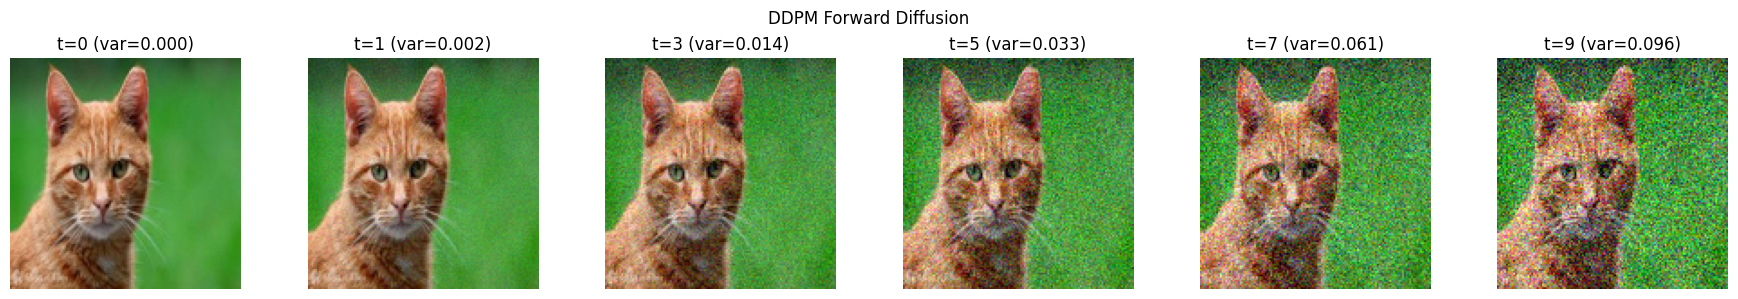

In [14]:
rng_forward = tf.random.Generator.from_seed(42)

def q_sample(x0, t, rng):
    sqrt_abar = tf.sqrt(alphas_bar[t])
    sqrt_1m = tf.sqrt(1.0 - alphas_bar[t])
    eps = rng.normal(shape=x0.shape)
    xt = sqrt_abar * x0 + sqrt_1m * eps
    return xt, eps

steps = [0, 1, 3, 5, 7, 9]
images = []
titles = []
for t in steps:
    xt, _ = q_sample(x0, t, rng_forward)
    images.append(to_vis(xt))
    titles.append(f't={t} (var={float(1 - alphas_bar[t]):.3f})')

show_strip(images, titles, 'DDPM Forward Diffusion')


## 5.3 Forward Pass (SDE) <a class="anchor" id="53-forward-pass-sde"></a>


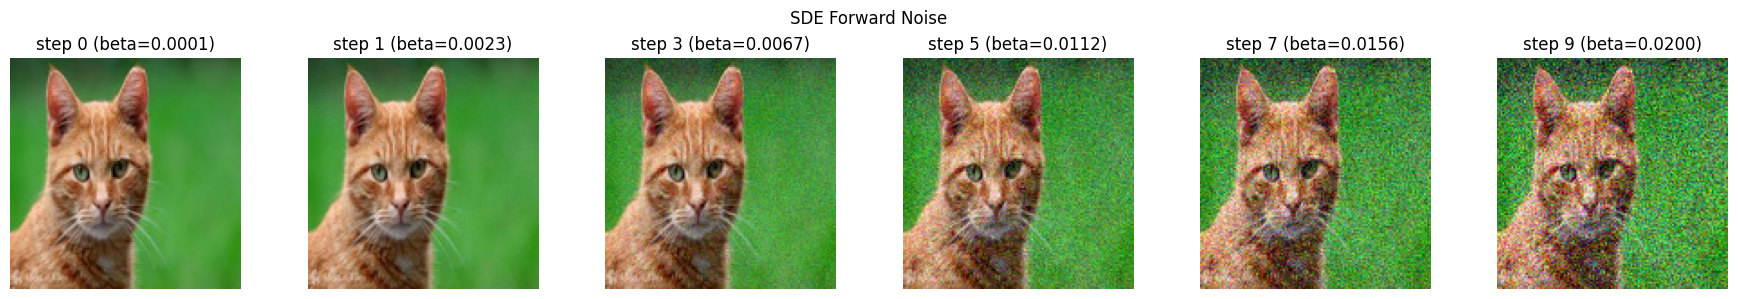

In [15]:
rng_sde = tf.random.Generator.from_seed(123)

def sde_forward_path(x0, steps=10):
    x = tf.identity(x0)
    path = [x]
    for t in range(steps):
        beta_t = betas[t]
        f = -0.5 * beta_t * x
        g = tf.sqrt(beta_t)
        dw = rng_sde.normal(shape=x.shape)
        x = x + f + g * dw
        x = tf.clip_by_value(x, -1.0, 1.0)
        path.append(x)
    return path

sde_path = sde_forward_path(x0, steps=T)
steps_show = [0, 1, 3, 5, 7, 9]
images = [to_vis(sde_path[t]) for t in steps_show]
titles = [f'step {t} (beta={float(betas[t]):.4f})' for t in steps_show]

show_strip(images, titles, 'SDE Forward Noise')


## 5.4 Simple U-Net (Shared) <a class="anchor" id="54-simple-u-net-shared"></a>


In [16]:
def build_simple_unet(img_size=128, channels=3, time_dim=32, name='simple_unet'):
    img_in = tf.keras.Input(shape=(img_size, img_size, channels), name='x_t')
    t_in = tf.keras.Input(shape=(1,), name='t')

    t = tf.keras.layers.Dense(time_dim, activation='relu')(t_in)
    t = tf.keras.layers.Dense(img_size * img_size, activation='relu')(t)
    t = tf.keras.layers.Reshape((img_size, img_size, 1))(t)

    x = tf.keras.layers.Concatenate()([img_in, t])

    c1 = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    c1 = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(c1)
    p1 = tf.keras.layers.MaxPool2D()(c1)

    c2 = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(p1)
    c2 = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(c2)
    p2 = tf.keras.layers.MaxPool2D()(c2)

    b = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(p2)
    b = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(b)

    u1 = tf.keras.layers.UpSampling2D()(b)
    u1 = tf.keras.layers.Concatenate()([u1, c2])
    c3 = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(u1)
    c3 = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(c3)

    u2 = tf.keras.layers.UpSampling2D()(c3)
    u2 = tf.keras.layers.Concatenate()([u2, c1])
    c4 = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(u2)
    c4 = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(c4)

    out = tf.keras.layers.Conv2D(3, 1, padding='same', activation=None)(c4)
    return tf.keras.Model([img_in, t_in], out, name=name)

unet = build_simple_unet()
unet.summary()


Model: "simple_unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ t (InputLayer)      │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │         64 │ t[0][0]           │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16384)     │    540,672 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x_t (InputLayer)    │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 128, 128,  │          0 │ dense_1[0][0]     │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ x_t[0][0],        │
│ (Concatenate)       │ 4)                │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,184 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64,    │          0 │ up_sampling2d_2[… │
│ (Concatenate)       │ 192)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    110,656 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_6[0][0]  

 Total params: 1,012,643 (3.86 MB)

 Trainable params: 1,012,643 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

## 5.5 Reverse Pass (DDPM) <a class="anchor" id="55-reverse-pass-ddpm"></a>


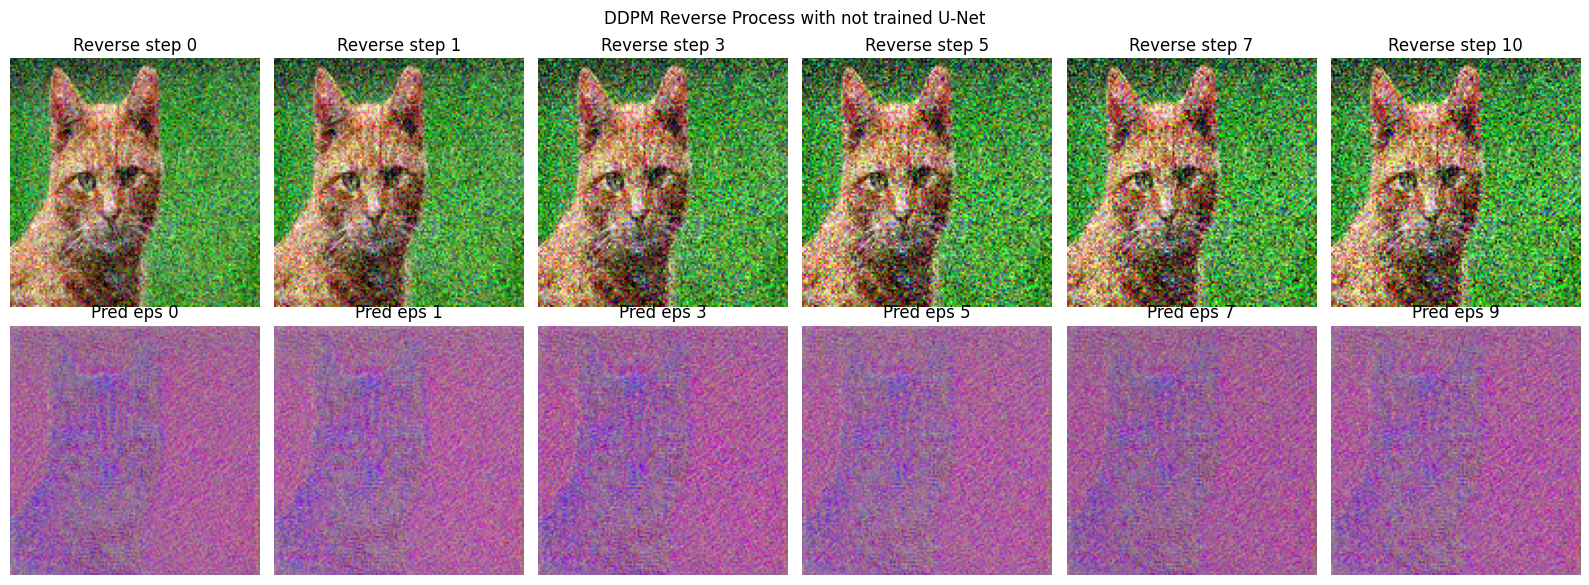

In [17]:
rng_reverse = tf.random.Generator.from_seed(999)

def p_sample(unet, xt, t, rng):
    xt_batch = xt[None, ...]
    t_batch = tf.constant([[t / (T - 1)]], dtype=tf.float32)

    eps_theta = unet([xt_batch, t_batch], training=False)[0]

    alpha_t = alphas[t]
    alpha_bar_t = alphas_bar[t]
    beta_t = betas[t]

    mu = (1.0 / tf.sqrt(alpha_t)) * (
        xt - ((1.0 - alpha_t) / tf.sqrt(1.0 - alpha_bar_t)) * eps_theta
    )

    if t > 0:
        z = rng.normal(shape=xt.shape)
        x_prev = mu + tf.sqrt(beta_t) * z
    else:
        x_prev = mu

    return x_prev, eps_theta

# Start from x_T generated by q(x_T | x0)
xT, _ = q_sample(x0, T - 1, rng_forward)

reverse_steps = [xT.numpy()]
pred_noises = []

x_curr = xT
for t in reversed(range(T)):
    x_curr, eps_theta = p_sample(unet, x_curr, t, rng_reverse)
    reverse_steps.append(tf.clip_by_value(x_curr, -1, 1).numpy())
    pred_noises.append(eps_theta.numpy())

fig, axs = plt.subplots(2, 6, figsize=(16, 6))
show_ids = [0, 1, 3, 5, 7, 10]
for i, idx in enumerate(show_ids):
    img_vis = np.clip((reverse_steps[idx] + 1) / 2, 0, 1)
    axs[0, i].imshow(img_vis)
    axs[0, i].set_title(f'Reverse step {idx}')
    axs[0, i].axis('off')

for i, idx in enumerate([0, 1, 3, 5, 7, 9]):
    noise_vis = pred_noises[idx]
    noise_vis = (noise_vis - noise_vis.min()) / (noise_vis.max() - noise_vis.min() + 1e-8)
    axs[1, i].imshow(noise_vis)
    axs[1, i].set_title(f'Pred eps {idx}')
    axs[1, i].axis('off')

plt.suptitle('DDPM Reverse Process with not trained U-Net')
plt.tight_layout()
plt.show()


## 5.6 Reverse Pass (SDE) <a class="anchor" id="56-reverse-pass-sde"></a>


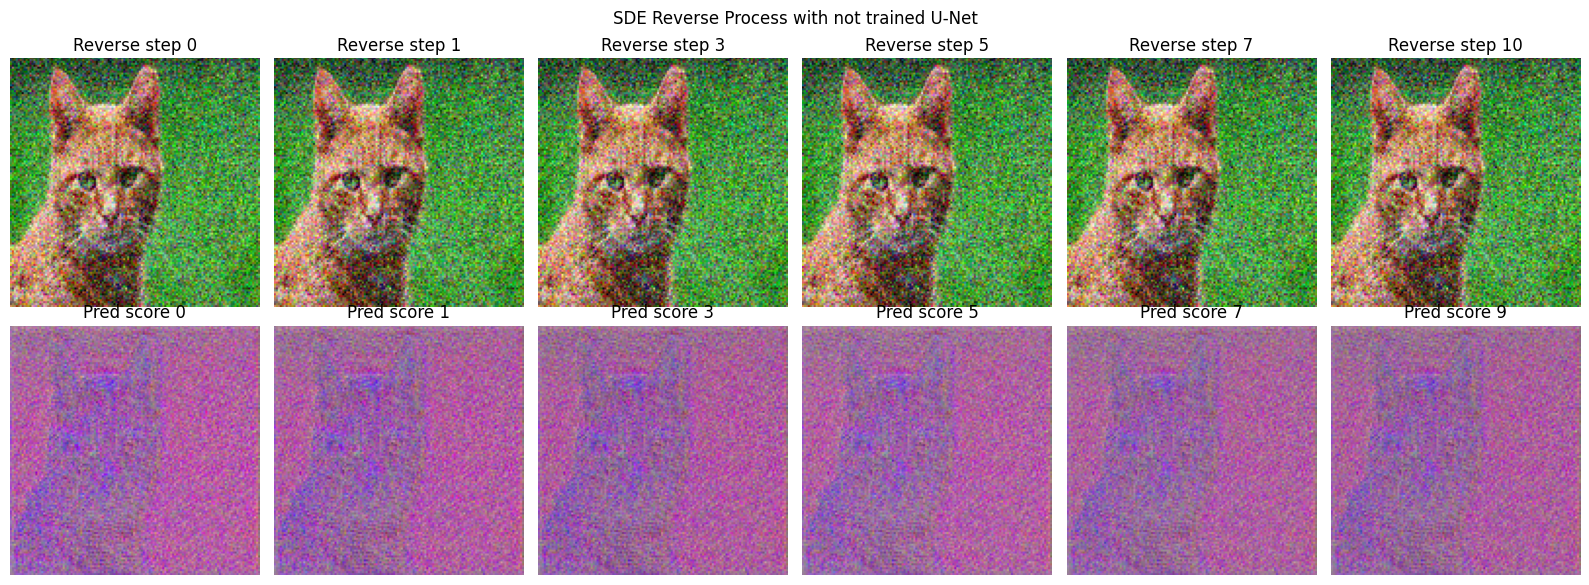

In [19]:
def reverse_sde_step(unet, xt, t_idx, dt=0.1):
    beta_t = betas[t_idx]
    g_t = tf.sqrt(beta_t)

    xt_batch = xt[None, ...]
    t_batch = tf.constant([[t_idx / (T - 1)]], dtype=tf.float32)

    score_theta = unet([xt_batch, t_batch], training=False)[0]

    f = -0.5 * beta_t * xt
    drift = f - (g_t ** 2) * score_theta

    dw_bar = tf.random.normal(shape=xt.shape) * tf.sqrt(dt)
    x_prev = xt + drift * dt + g_t * dw_bar

    return tf.clip_by_value(x_prev, -1.0, 1.0), score_theta

# Start from the last point in the forward SDE path
xT_sde = sde_path[-1]

x = tf.identity(xT_sde)
reverse_path = [x.numpy()]
score_path = []

for t in reversed(range(T)):
    x, score_theta = reverse_sde_step(unet, x, t, dt=0.1)
    reverse_path.append(x.numpy())
    score_path.append(score_theta.numpy())

fig, axs = plt.subplots(2, 6, figsize=(16, 6))
show_ids = [0, 1, 3, 5, 7, 10]
for i, idx in enumerate(show_ids):
    img_vis = np.clip((reverse_path[idx] + 1) / 2, 0, 1)
    axs[0, i].imshow(img_vis)
    axs[0, i].set_title(f'Reverse step {idx}')
    axs[0, i].axis('off')

for i, idx in enumerate([0, 1, 3, 5, 7, 9]):
    score_vis = score_path[idx]
    score_vis = (score_vis - score_vis.min()) / (score_vis.max() - score_vis.min() + 1e-8)
    axs[1, i].imshow(score_vis)
    axs[1, i].set_title(f'Pred score {idx}')
    axs[1, i].axis('off')

plt.suptitle('SDE Reverse Process with not trained U-Net')
plt.tight_layout()
plt.show()


The above implementation illustrates how the DDPM and SDE formulations are realized in practice. Although the U-Net used here is not trained and is included only for demonstration, a separate case study is provided in which students fine-tune a diffusion model using Dreambooth on a small dataset of 10 to 20 images.

# References <a class="anchor" id="6-references"></a>

1) <a id="ref-1"></a> Ho, J., Jain, A., & Abbeel, P. (2020). Denoising Diffusion Probabilistic Models. arXiv:2006.11239. https://doi.org/10.48550/arXiv.2006.11239
2) <a id="ref-2"></a> Kingma, D. P., & Gao, R. (2023). *Understanding Diffusion Objectives as the ELBO with Simple Data Augmentation*. arXiv:2303.00848. https://doi.org/10.48550/arXiv.2303.00848
3) <a id="ref-3"></a> Dhariwal, P., & Nichol, A. (2021). *Diffusion Models Beat GANs on Image Synthesis*. arXiv:2105.05233. https://doi.org/10.48550/arXiv.2105.05233
4) <a id="ref-4"></a> Weng, Lilian. (Jul 2021). What are diffusion models? Lil’Log. https://lilianweng.github.io/posts/2021-07-11-diffusion-models/.
5) <a id="ref-5"></a> Miao, Yanting, Loh, William, Kothawade, Suraj & Poupart, Pascal. (May 2025). A Minimalist Method for Fine-tuning Text-to-Image Diffusion Models. arXiv:2506.12036.
6) <a id="ref-6"></a> Yuan, Huizhuo, Chen, Zixiang, Ji, Kaixuan & Gu, Quanquan. (Feb 2024). Self-Play Fine-Tuning of Diffusion Models for Text-to-Image Generation. arXiv:2402.10210. https://doi.org/10.48550/arXiv.2402.10210
7) <a id="ref-7"></a> Uehara, Masatoshi, Zhao, Yulai, Biancalani, Tommaso & Levine, Sergey. (Jul 2024). Understanding Reinforcement Learning-Based Fine-Tuning of Diffusion Models: A Tutorial and Review. arXiv:2407.13734. https://doi.org/10.48550/arXiv.2407.13734
8) <a id="ref-8"></a> Dang, Meihua, Singh, Anikait, Zhou, Linqi, Ermon, Stefano & Song, Jiaming. (n.d.). Personalized Preference Fine-tuning of Diffusion Models.
9) <a id="ref-9"></a> Ho, Jonathan & Salimans, Tim. (Jul 2022). Classifier-Free Diffusion Guidance. arXiv:2207.12598. https://doi.org/10.48550/arXiv.2207.12598
10) <a id="ref-10"></a> Song, Y., Sohl-Dickstein, J., Kingma, D. P., Kumar, A., Ermon, S., & Poole, B. (2021). Score-Based Generative Modeling through Stochastic Differential Equations. arXiv:2011.13456. https://doi.org/10.48550/arXiv.2011.13456
11) <a id="ref-11"></a> Kingma, D. P., & Welling, M. (2014) Auto-Encoding Variational Bayes. *Proceedings of the 2nd International Conference on Learning Representations (ICLR 2014).* https://doi.org/10.48550/arXiv.1312.6114
12) <a id="ref-12"></a> Yang, L., Zhang, Z., Song, Y., Hong, S., Xu, R., Zhao, Y., Zhang, W., Cui, B., & Yang, M.-H.  *Diffusion Models: A Comprehensive Survey of Methods and Applications.*  ACM Computing Surveys, 2023.  arXiv:2209.00796. https://doi.org/10.48550/arXiv.2209.00796
13) <a id="ref-13"></a> Luo, C. *Understanding Diffusion Models: A Unified Perspective.*  arXiv:2208.11970, 2022. https://arxiv.org/pdf/2208.11970 
14) <a id="ref-14"></a> Ruiz, N., Li, Y., Jampani, V., Pritch, Y., Rubinstein, M., & Aberman, K. *DreamBooth: Fine Tuning Text-to-Image Diffusion Models for Subject-Driven Generation.*  CVPR 2023.  arXiv:2208.12242 https://doi.org/10.48550/arXiv.2208.12242
15) <a id="ref-15"></a> V. Badrinarayanan, A. Kendall and R. Cipolla, "SegNet: A Deep Convolutional Encoder-Decoder Architecture for Image Segmentation,"  2017, doi: 10.1109/TPAMI.2016.2644615.
16) <a id="ref-16"></a> K. Laxman, S. R. Dubey, B. Kalyan, S. R. V. Kojjarapu, *Efficient High-Resolution Image-to-Image Translation using Multi-Scale Gradient U-Net*, arXiv:2105.13067, 2021. **DOI:** https://doi.org/10.48550/arXiv.2105.13067
17) <a id="ref-17"></a> Berrada Ifriqi, T. et al., *On Improved Conditioning Mechanisms and Pre-training Strategies for Diffusion Models*, NeurIPS 2024. arXiv:2411.03177 — https://doi.org/10.48550/arXiv.2411.03177
18) <a id="ref-18"></a> A. Vahdat and J. Kautz. NVAE: A deep hierarchical variational autoencoder. In NeurIPS, 2020.
19) <a id="ref-19"></a> Kwonjoon Lee, Huiwen Chang, Lu Jiang, Han Zhang, Zhuowen Tu, and Ce Liu. ViTGAN: Training GANs with vision transformers. In ICLR, 2022.
20) <a id="ref-20"></a> MathWorks. (n.d.). dlarray.maxunpool — MATLAB documentation. https://www.mathworks.com/help/deeplearning/ref/dlarray.maxunpool.html
21) <a id="ref-21"></a> GeeksforGeeks. (n.d.). What is a Transposed Convolutional Layer? https://www.geeksforgeeks.org/machine-learning/what-is-transposed-convolutional-layer/
22) <a id="ref-22"></a> Bellman, R. (1961). Adaptive Control Processes: A Guided Tour. Princeton University Press.
23) <a id="ref-23"></a> Bengio, Y., Courville, A., & Vincent, P. (2013). Representation learning: A review and new perspectives. IEEE Transactions on Pattern Analysis and Machine Intelligence, 35(8), 1798-1828.
24) <a id="ref-24"></a> Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.
25) <a id="ref-25"></a> Hinton, G. E., & Salakhutdinov, R. R. (2006). Reducing the dimensionality of data with neural networks. Science, 313(5786), 504-507.
26) <a id="ref-26"></a> Jolliffe, I. T. (2002). Principal Component Analysis. Springer. (Chapter 4: Linear Models for Classification)
27) <a id="ref-27"></a> Sakurada, M., & Yairi, T. (2014). Anomaly detection using autoencoders with nonlinear dimensionality reduction. Proceedings of the MLSDA 2014 2nd Workshop on Machine Learning for Sensory Data Analysis.
28) <a id="ref-28"></a> Vincent, P., Larochelle, H., Lajoie, I., Bengio, Y., & Manzagol, P.-A. (2008). Stacked denoising autoencoders: Learning useful representations in a deep network with a local denoising criterion. Journal of Machine Learning Research, 11, 3371-3408.
29) <a id="ref-29"></a> Bergstra, J., & Bengio, Y. (2012). Random search for hyper-parameter optimization. Journal of Machine Learning Research, 13(1), 281-305.
30) <a id="ref-30"></a> Collobert, R., & Weston, J. (2008). A unified architecture for natural language processing: Deep neural networks with multitask learning. Proceedings of the 25th International Conference on Machine Learning (ICML).
31) <a id="ref-31"></a> Cybenko, G. (1989). Approximation by superpositions of a sigmoidal function. Mathematics of Control, Signals, and Systems.
32) <a id="ref-32"></a> Doersch, C. (2016). Tutorial on Variational Autoencoders. arXiv:1606.05908.
33) <a id="ref-33"></a> Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation. In MICCAI 2015. arXiv:1505.04597.
34) <a id="ref-34"></a> van der Maaten, L., & Hinton, G. (2008). Visualizing Data using t-SNE. Journal of Machine Learning Research, 9, 2579-2605.
35) <a id="ref-35"></a> Ng, A. (2011). Sparse autoencoder. UFLDL Tutorial.
36) <a id="ref-36"></a> Rifai, S., Vincent, P., Muller, X., Glorot, X., & Bengio, Y. (2011). Contractive Auto-Encoders: Explicit invariance during feature extraction. ICML 2011.
37) <a id="ref-37"></a> Bao, F., Li, C., Sun, J., & Zhu, J. (2022). *Why Are Conditional Generative Models Better Than Unconditional Ones?*
arXiv. https://doi.org/10.48550/arXiv.2212.00362
38) <a id="ref-38"></a> Karras, T., Aittala, M., Kynkäänniemi, T., Lehtinen, J., Aila, T., & Laine, S. (2024). *[Guiding a Diffusion Model with a Bad Version of Itself](https://arxiv.org/abs/2406.02507)*. arXiv. https://arxiv.org/abs/2406.02507
39) <a id="ref-39"></a> Y. Ouyang, L. Xie, H. Zha, and G. Cheng, *Transfer Learning for Diffusion Models*, arXiv:2405.16876, 2024. https://doi.org/10.48550/arXiv.2405.16876
40) <a id="ref-40"></a> J. Zhong, X. Guo, J. Dong, and M. Long, Diffusion Tuning: Transferring Diffusion Models via Chain of Forgetting, arXiv:2406.00773, 2024. https://doi.org/10.48550/arXiv.2406.00773
41) <a id="ref-41"></a> G. Kim, T. Kwon, and J. C. Ye, *DiffusionCLIP: Text-Guided Diffusion Models for Robust Image Manipulation*, arXiv:2110.02711, 2021. https://doi.org/10.48550/arXiv.2110.02711
42) <a id="ref-42"></a> V. T. Hu, D. W. Zhang, Y. M. Asano, G. J. Burghouts, and C. G. M. Snoek, *Self-Guided Diffusion Models*, arXiv:2210.06462, 2023. https://doi.org/10.48550/arXiv.2210.06462
43) <a id="ref-43"></a> A. Bansal, H.-M. Chu, A. Schwarzschild, S. Sengupta, M. Goldblum, J. Geiping, and T. Goldstein, *Universal Guidance for Diffusion Models*, arXiv:2302.07121, 2023. https://doi.org/10.48550/arXiv.2302.07121
44) <a id="ref-44"></a> Z. Zhan, D. Chen, J.-P. Mei, Z. Zhao, J. Chen, C. Chen, S. Lyu, and C. Wang, *Conditional Image Synthesis with Diffusion Models: A Survey*, arXiv:2409.19365, 2024. https://doi.org/10.48550/arXiv.2409.19365
45) <a id="ref-45"></a> R. Rombach, A. Blattmann, D. Lorenz, P. Esser, and B. Ommer, *High-Resolution Image Synthesis with Latent Diffusion Models*, arXiv:2112.10752, 2021. https://doi.org/10.48550/arXiv.2112.10752
46) <a id="ref-46"></a> R. Gal, Y. Alaluf, Y. Atzmon, O. Patashnik, A. H. Bermano, G. Chechik, and D. Cohen-Or, *An Image is Worth One Word: Personalizing Text-to-Image Generation using Textual Inversion*, arXiv:2208.01618, 2022. https://doi.org/10.48550/arXiv.2208.01618
47) <a id="ref-47"></a> Z. Zhuang, Y. Zhang, X. Wang, J. Lu, Y. Wei, and Y. Zhang, *Time-Varying LoRA: Towards Effective Cross-Domain Fine-Tuning of Diffusion Models*, in *NeurIPS 2024*. [Link](https://openreview.net/forum?id=SgODU2mx9T)
48) <a id="ref-48"></a> Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. U-Net: Convolutional Networks for Biomedical Image Segmentation. In Proceedings of the International Conference on Medical Image Computing and Computer-Assisted Intervention (MICCAI), pp. 234–241. Springer, 2015.
49) <a id="ref-49"></a> LIU Q G, GUAN Y, WU W W, et al. Diffusion Models in Medical Imaging: A Comprehensive Survey[J]. CT Theory and Applications, 2025, 34(3): 506-524. DOI: 10.15953/j.ctta.2024.316. (in Chinese).
50) <a id="ref-50"></a> ROMBACH R, BLATTMANN A, LORENZ D, et al. High-Resolution Image Synthesis with Latent Diffusion Models[EB/OL]. arXiv, 2022. DOI: 10.48550/arXiv.2112.10752.
51) <a id="ref-51"></a> WOLF R, SHI Y, LIU S, et al. Diffusion Models for Robotic Manipulation: A Survey[EB/OL]. arXiv, 2025. DOI: 10.48550/arXiv.2504.08438.







